/kaggle/input/datasets/khusingh8/sleepdataset/Health_Sleep_Statistics.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   User ID                  100 non-null    int64 
 1   Age                      100 non-null    int64 
 2   Gender                   100 non-null    object
 3   Sleep Quality            100 non-null    int64 
 4   Bedtime                  100 non-null    object
 5   Wake-up Time             100 non-null    object
 6   Daily Steps              100 non-null    int64 
 7   Calories Burned          100 non-null    int64 
 8   Physical Activity Level  100 non-null    object
 9   Dietary Habits           100 non-null    object
 10  Sleep Disorders          100 non-null    object
 11  Medication Usage         100 non-null    object
dtypes: int64(5), object(7)
memory usage: 9.5+ KB


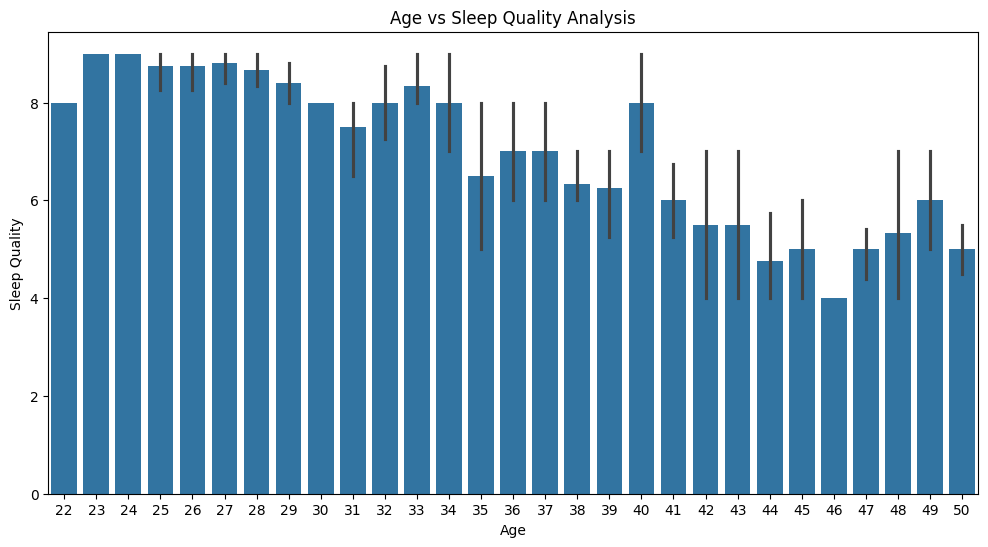

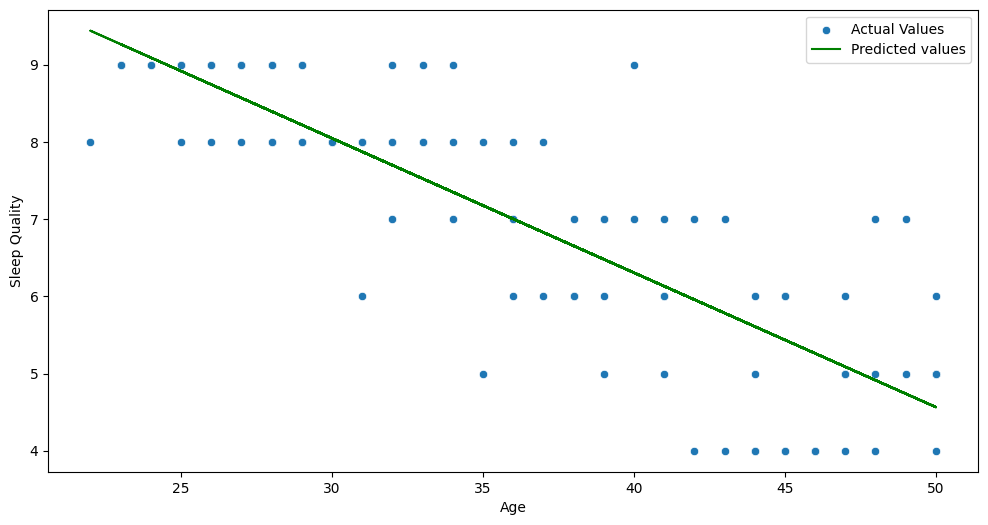

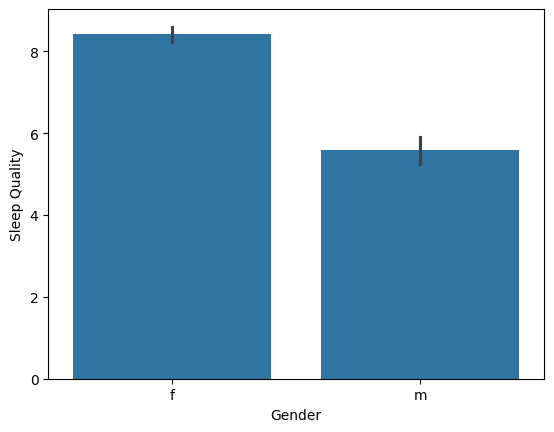

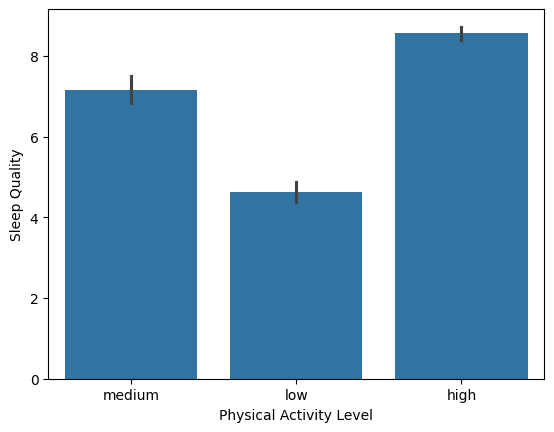

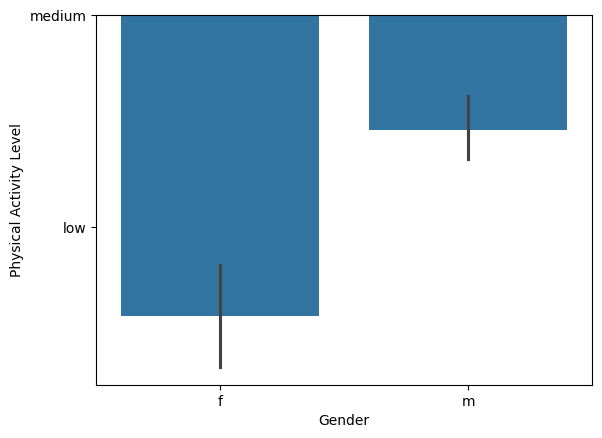

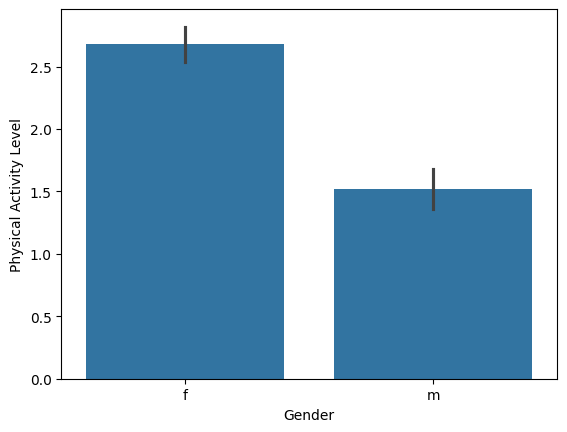

t_stats value for Sleep Quality vs gender : -14.32
p_stats value for Sleep Quality vs gender : 0.00
t_stats value for Physical_Activity vs gender : -10.98
p_stats value for Physical_Activity vs gender : 0.00


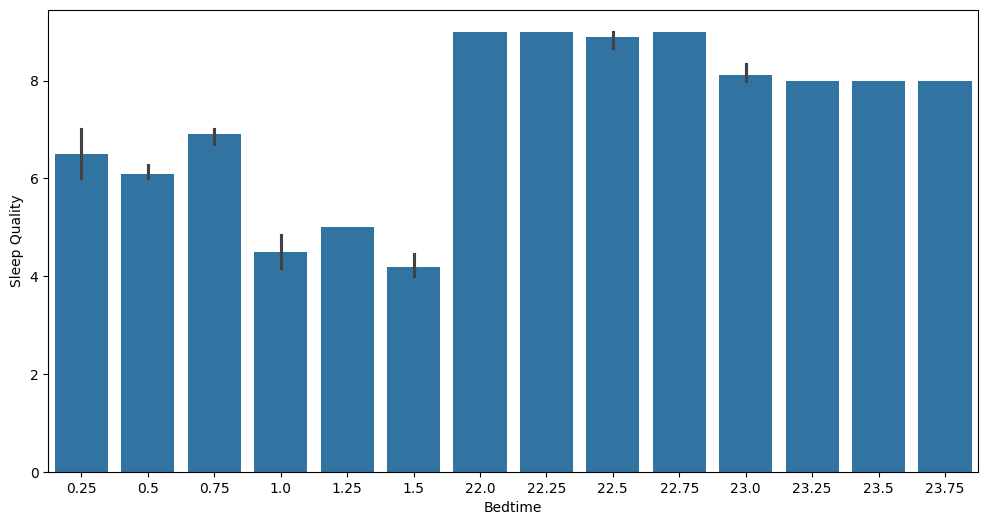

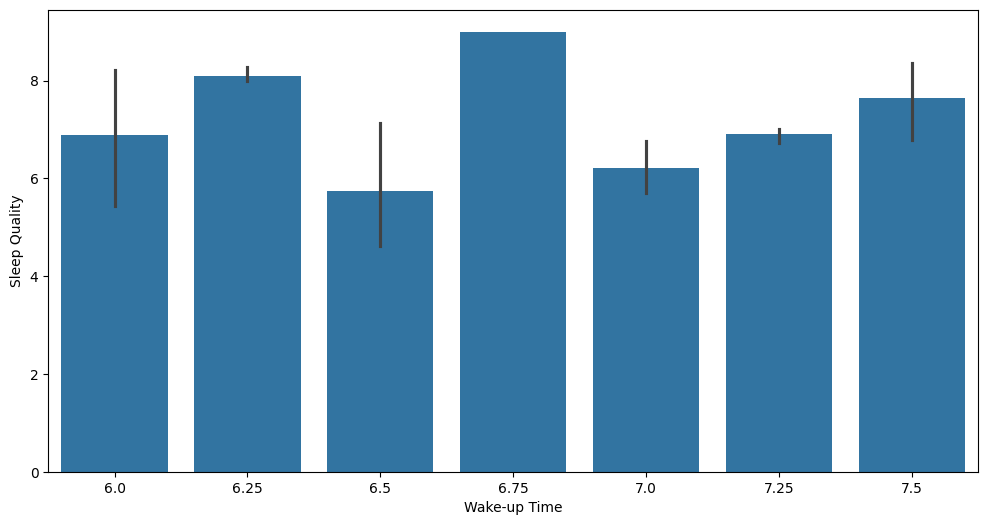

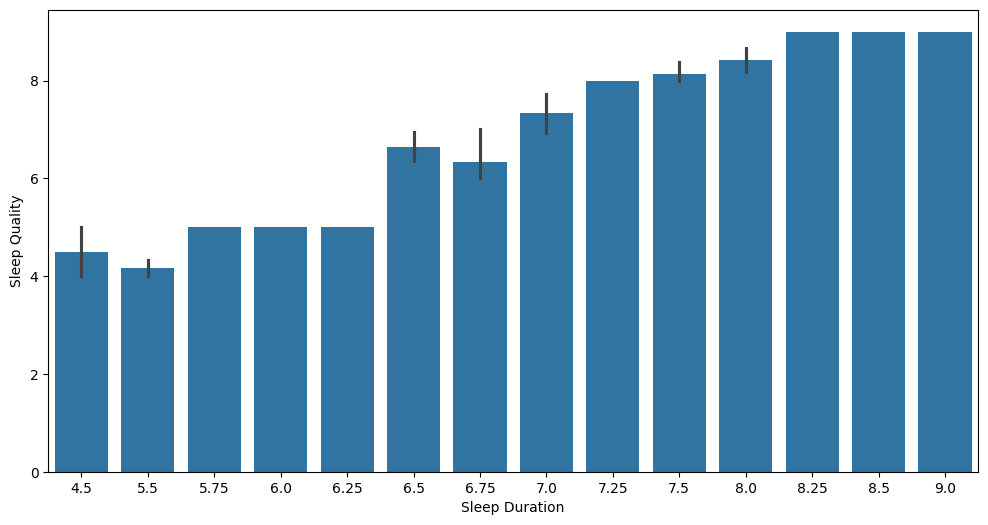

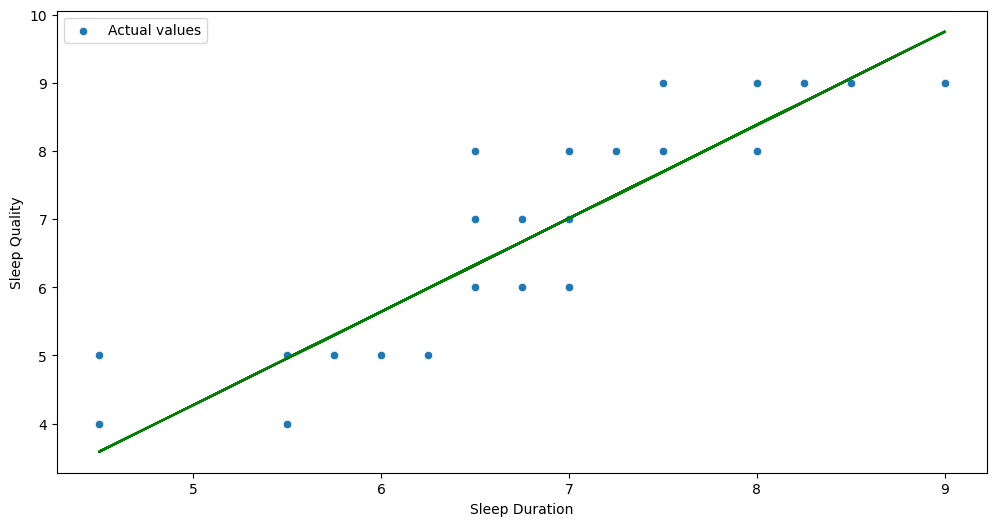

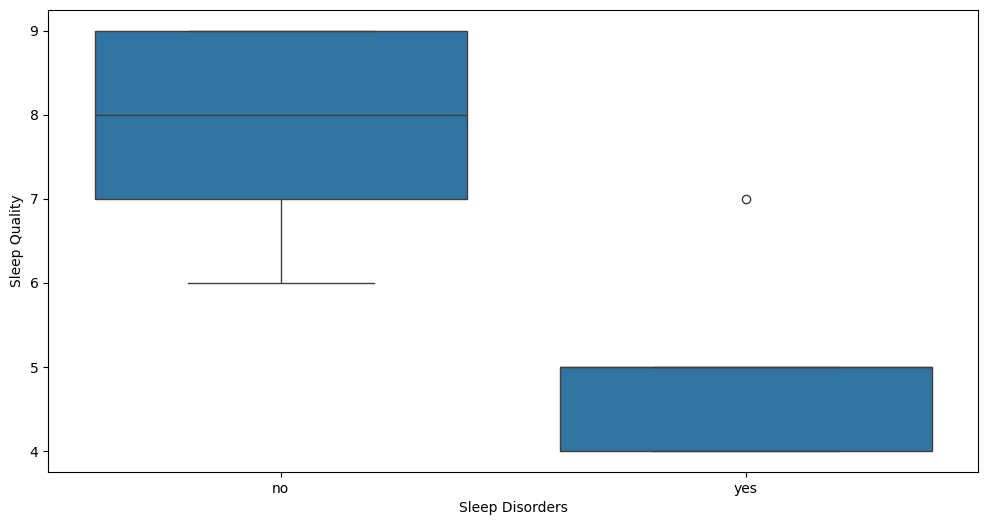

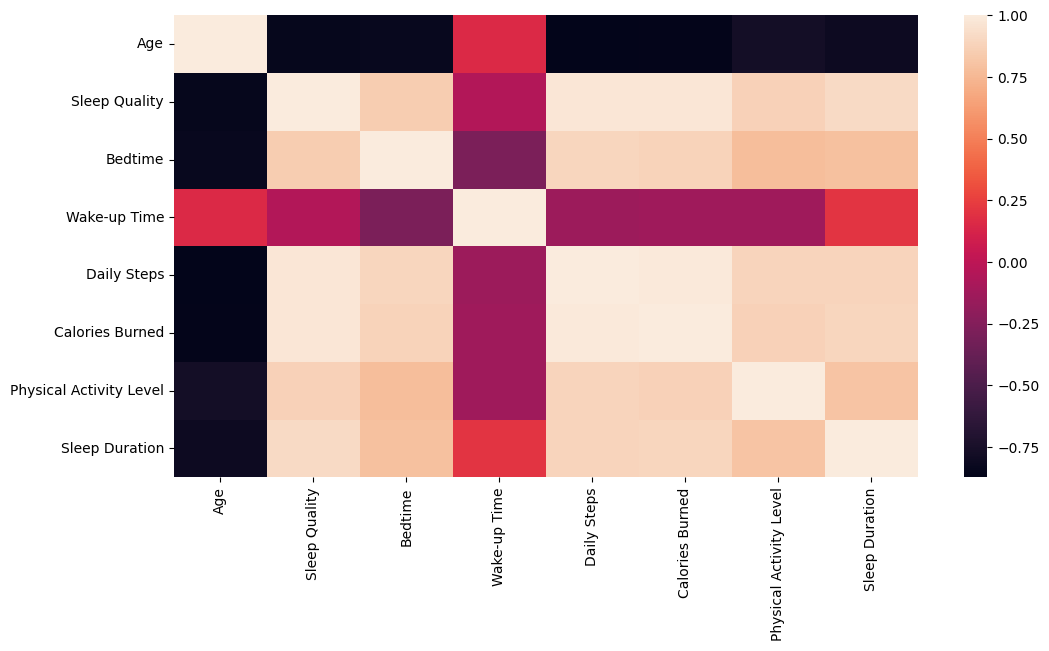

In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for creating graphs and charts
import seaborn as sns # visualization lib


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# create dataframe and import data
df = pd.read_csv(f'//kaggle/input/datasets/khusingh8/sleepdataset/Health_Sleep_Statistics.csv')
df.head()

# see the size of the data frame
df.size

# see the columns of the data 
df.columns

# see the datatype of the columns 
df.info()

# give agrregation
df.describe()

# find null values
df.isna().sum()

# find duplicate values
df.duplicated().sum()

# remove user_id column
df.drop(['User ID'], axis = 1, inplace = True)
df.columns

# New Graph - 1
# Age vs sleep quality analysis # age is inverserly proportional to sleep
age_sleep_quality_corr = df[['Age','Sleep Quality']].corr()
age_sleep_quality_corr
 # Analysis  = age is inversely proportional to sleep

#visualize the above relationship
# see the graph
plt.figure(figsize = (12,6))
sns.barplot(x = 'Age', y ='Sleep Quality', data = df)
plt.title("Age vs Sleep Quality Analysis")
plt.xlabel("Age")
plt.ylabel("Sleep Quality")
plt.show()

#visualize the above relationship in simple linear model
from sklearn.linear_model import LinearRegression
age_sleep_quality_model = LinearRegression()

x = df[['Age']]
y = df['Sleep Quality']

age_sleep_quality_model.fit(x,y)
# check the intercept
age_sleep_quality_model.intercept_
# check the slope
age_sleep_quality_model.coef_

#Age Sleep Quality Predictions - using the model predict data of sleep quality with age

Age_Sleep_Quality_Predictions = age_sleep_quality_model.predict(x)

#plot a graph on the above 
plt.figure(figsize = (12,6))
sns.scatterplot(x ='Age',y = 'Sleep Quality',data= df, label =  'Actual Values')
plt.plot (x, Age_Sleep_Quality_Predictions, color ='green', label = "Predicted values")
plt.legend()
plt.show()

# New Graph - 2
# Physical Activity vs Sleep Quality

# See values of the column
df['Physical Activity Level'].head()

#See sleep quality of M vs F
sns.barplot(x = 'Gender', y ='Sleep Quality', data = df)
plt.show()


#See sleep quality of physical Activity

sns.barplot(x = "Physical Activity Level", y = "Sleep Quality", data = df)
plt.show()


#See physical Activity of M and F

sns.barplot(x = "Gender", y = "Physical Activity Level", data = df)
plt.show()

# in Y axis numerical Values are expected so we have to change Physical Activity Level column 
# to mumeric values
custom_code ={'low': 1, 'medium': 2, 'high' : 3}
df['Physical Activity Level'] = df['Physical Activity Level'].map(custom_code)
df['Physical Activity Level'].head()
sns.barplot(x = "Gender", y = "Physical Activity Level", data = df)
plt.show()


# calculate T and P values of gender vs sleep quality

#Find T value
from scipy import stats

# which rows are male roles and sleep quality of male
sleep_quality_males = df[df['Gender'] == 'm']['Sleep Quality'] 

# which rows are female roles and sleep quality of male
sleep_quality_females = df[df['Gender'] == 'f']['Sleep Quality'] 

# which rows are male roles and physical activity  of male
physical_activity_males = df[df['Gender'] == 'm']['Physical Activity Level'] 

# which rows are female roles and physical activity of male
physical_activity_females = df[df['Gender'] == 'f']['Physical Activity Level'] 

# Find out T and P values for Sleep Quality Vs gender & physical activity vs gender

t_sleep_quality, p_sleep_quality = stats.ttest_ind(sleep_quality_males,sleep_quality_females)
print(f"t_stats value for Sleep Quality vs gender : {t_sleep_quality:.2f}" )
print(f"p_stats value for Sleep Quality vs gender : {p_sleep_quality:.2f}" )

# Find out T and P values physical activity vs gender
t_Physical_Activity, p_Physical_Activity = stats.ttest_ind(physical_activity_males,physical_activity_females)
print(f"t_stats value for Physical_Activity vs gender : {t_Physical_Activity:.2f}" )
print(f"p_stats value for Physical_Activity vs gender : {p_Physical_Activity:.2f}" )

#Time of waking Up and sleep time  Vs Sleep Quality

#Show data of bedtime & wakeup time column
df['Bedtime']
df['Wake-up Time']
#convert into numbers - helper function - takes string time and split it in colon
def sleep_time_helper_function(str_time):
    h = int(str_time.split(":")[0])
    m = int(str_time.split(":")[1])
    return h + m / 60

df['Bedtime'] = df['Bedtime'].apply(sleep_time_helper_function)
df['Wake-up Time'] = df['Wake-up Time'].apply(sleep_time_helper_function)

df['Bedtime'].head()     

#create sleep duration column

df['Sleep Duration'] = (df['Wake-up Time'] - df['Bedtime'])%24
df['Sleep Duration'].head()

#See complete Dataset
df.head()

# Bedtime vs sleep Quality
plt.figure(figsize = (12,6))
sns.barplot(x = "Bedtime", y = "Sleep Quality", data = df)
plt.show()

# wake up time  vs sleep Quality
plt.figure(figsize = (12,6))
sns.barplot(x = "Wake-up Time", y = "Sleep Quality", data = df)
plt.show()

#Sleep Duration Hours vs sleep quality
plt.figure(figsize = (12,6))
sns.barplot(x = "Sleep Duration", y = "Sleep Quality", data = df)
plt.show()

# create sleep duration Quality linear model 

sleep_duration_quality_model = LinearRegression()
x = df[['Sleep Duration']]
y = df[['Sleep Quality']]
sleep_duration_quality_model.fit(x,y)

# find out coffecient
sleep_duration_quality_model.coef_

# find out intercept
sleep_duration_quality_model.intercept_

# Plot Predictions 
predictions = sleep_duration_quality_model.predict(x)

plt.figure(figsize = (12,6))

sns.scatterplot(x = "Sleep Duration", y = "Sleep Quality", data = df, label ='Actual values')
plt.plot( x, predictions, color ='green', label = 'Predicted values')
plt.legend
plt.show()

# Sleep diosorder using a box plot
#Sleep Disorder vs Sleep Qulaity

plt.figure(figsize = (12,6))
sns.boxplot (x = "Sleep Disorders", y = "Sleep Quality", data = df)
plt.show()


# Select all numeric columns (int, float, etc.)
numeric_features = df.select_dtypes(include='number')

# Display the first 5 rows
numeric_features.head()

# plt heatmap 
plt.figure(figsize = (12,6))
sns.heatmap(numeric_features.corr())
plt.show()


































